In [2]:
!pwd
!ls -al ~/work

/home/jovyan
total 2840
drwxrwsr-x 14 root   users    4096 Jun 12 07:15 .
drwsrws---  1 jovyan users    4096 Jun 12 07:14 ..
drwxrwsr-x  2 jovyan users    4096 Jun 12 07:15 .ipynb_checkpoints
drwxrwsr-x  4 jovyan users    4096 Jun 12 07:15 data
drwxrwsr-x  5 jovyan users    4096 Jun 10 03:37 data_augmentation
drwxrwsr-x  3 jovyan users    4096 May 15 05:24 data_preprocess
drwxrwsr-x  5 jovyan users    4096 Jun  2 00:43 human_segmentation
-rw-rw-r--  1 jovyan users 2831720 Jun  5 03:32 human_segmentation_cat.ipynb
drwxrws---  2 root   users   16384 May 11 05:13 lost+found
drwxrwsr-x  2 jovyan users    4096 May 18 06:01 pokemon
drwxrwsr-x  3 jovyan users    4096 May 18 07:08 pokemon_eda
drwxrwsr-x  4 jovyan users    4096 May 15 08:18 project
drwxr-sr-x  3 jovyan users    4096 Jun 12 06:47 sentiment_classification
drwxrwsr-x  2 jovyan users    4096 Jun 11 01:44 word_embedding
drwxrwsr-x  4 jovyan users    4096 Jun  2 08:06 workplace


In [3]:
!mkdir -p ~/work/sentiment_classification
!ls -al ~/work

total 2840
drwxrwsr-x 14 root   users    4096 Jun 12 07:15 .
drwsrws---  1 jovyan users    4096 Jun 12 07:14 ..
drwxrwsr-x  2 jovyan users    4096 Jun 12 07:15 .ipynb_checkpoints
drwxrwsr-x  4 jovyan users    4096 Jun 12 07:15 data
drwxrwsr-x  5 jovyan users    4096 Jun 10 03:37 data_augmentation
drwxrwsr-x  3 jovyan users    4096 May 15 05:24 data_preprocess
drwxrwsr-x  5 jovyan users    4096 Jun  2 00:43 human_segmentation
-rw-rw-r--  1 jovyan users 2831720 Jun  5 03:32 human_segmentation_cat.ipynb
drwxrws---  2 root   users   16384 May 11 05:13 lost+found
drwxrwsr-x  2 jovyan users    4096 May 18 06:01 pokemon
drwxrwsr-x  3 jovyan users    4096 May 18 07:08 pokemon_eda
drwxrwsr-x  4 jovyan users    4096 May 15 08:18 project
drwxr-sr-x  3 jovyan users    4096 Jun 12 06:47 sentiment_classification
drwxrwsr-x  2 jovyan users    4096 Jun 11 01:44 word_embedding
drwxrwsr-x  4 jovyan users    4096 Jun  2 08:06 workplace


In [4]:
%cd ~/work/sentiment_classification
!pwd

/home/jovyan/work/sentiment_classification
/home/jovyan/work/sentiment_classification


In [5]:
!pip install gensim==4.3.2

In [6]:
!conda install scipy==1.12.0 numpy==1.26.3 -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [7]:
import numpy as np
import scipy
import gensim

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("gensim:", gensim.__version__)

numpy: 1.26.3
scipy: 1.12.0
gensim: 4.3.2


In [1]:
!ln -s /home/jovyan/data /home/jovyan/work/sentiment_classification/
!ls -al ~/work/sentiment_classification

ln: failed to create symbolic link '/home/jovyan/work/sentiment_classification/data': File exists
total 12
drwxr-sr-x  3 jovyan users 4096 Jun 12 06:47 .
drwxrwsr-x 14 root   users 4096 Jun 12 07:15 ..
lrwxrwxrwx  1 jovyan users   17 Jun 12 03:35 data -> /home/jovyan/data
drwxr-sr-x  2 jovyan users 4096 Jun 12 06:47 word2vec_emb


In [2]:
!ln -s /home/jovyan/data /home/jovyan/work/sentiment_classification/
!ls -al ~/work/sentiment_classification

ln: failed to create symbolic link '/home/jovyan/work/sentiment_classification/data': File exists
total 12
drwxr-sr-x  3 jovyan users 4096 Jun 12 06:47 .
drwxrwsr-x 14 root   users 4096 Jun 12 07:15 ..
lrwxrwxrwx  1 jovyan users   17 Jun 12 03:35 data -> /home/jovyan/data
drwxr-sr-x  2 jovyan users 4096 Jun 12 06:47 word2vec_emb


In [3]:
!ls -al ~/work/sentiment_classification/data

lrwxrwxrwx 1 jovyan users 17 Jun 12 03:35 /home/jovyan/work/sentiment_classification/data -> /home/jovyan/data


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

print("준비 완료!")
print("현재 작업 폴더:", os.getcwd())

준비 완료!
현재 작업 폴더: /home/jovyan


In [5]:
%cd ~/work/sentiment_classification
!pwd
!ls -al

/home/jovyan/work/sentiment_classification
/home/jovyan/work/sentiment_classification
total 12
drwxr-sr-x  3 jovyan users 4096 Jun 12 06:47 .
drwxrwsr-x 14 root   users 4096 Jun 12 07:15 ..
lrwxrwxrwx  1 jovyan users   17 Jun 12 03:35 data -> /home/jovyan/data
drwxr-sr-x  2 jovyan users 4096 Jun 12 06:47 word2vec_emb


In [6]:
!ls -al ~/work/sentiment_classification/data/

total 1912058
-rw-rw-r-- 1 root users 1647046227 Jun 17  2025 GoogleNews-vectors-negative300.bin.gz
-rw-rw-r-- 1 root users    1247853 Jun 19  2025 imdb_word_to_index.pickle
-rw-rw-r-- 1 root users   13498767 Jun 17  2025 imdb_x_test.npy
-rw-rw-r-- 1 root users   13967480 Jun 17  2025 imdb_x_train.npy
-rw-rw-r-- 1 root users     200128 Jun 17  2025 imdb_y_test.npy
-rw-rw-r-- 1 root users     200128 Jun 17  2025 imdb_y_train.npy
-rw-rw-r-- 1 root users    4893335 Jun 17  2025 ratings_test.txt
-rw-rw-r-- 1 root users   14628807 Jun 17  2025 ratings_train.txt
-rw-rw-r-- 1 root users   19893395 Jun 17  2025 word2vec_ko.model
-rw-rw-r-- 1 root users  121184128 Jun 17  2025 word2vec_ko.model.trainables.syn1neg.npy
-rw-rw-r-- 1 root users  121184128 Jun 17  2025 word2vec_ko.model.wv.vectors.npy


In [7]:
import os
import numpy as np

data_dir = os.path.join(os.getenv('HOME'), 'work/sentiment_classification/data/')

x_train = np.load(data_dir + 'imdb_x_train.npy', allow_pickle=True)
y_train = np.load(data_dir + 'imdb_y_train.npy', allow_pickle=True)
x_test = np.load(data_dir + 'imdb_x_test.npy', allow_pickle=True)
y_test = np.load(data_dir + 'imdb_y_test.npy', allow_pickle=True)

print(f"훈련 샘플 개수: {len(x_train)}")
print(f"테스트 샘플 개수: {len(x_test)}")
print(f"훈련 라벨 개수: {len(y_train)}")
print(f"테스트 라벨 개수: {len(y_test)}")

훈련 샘플 개수: 25000
테스트 샘플 개수: 25000
훈련 라벨 개수: 25000
테스트 라벨 개수: 25000


In [8]:
print(x_train[0])
print('라벨:', y_train[0])
print('1번째 리뷰 문장 길이:', len(x_train[0]))
print('2번째 리뷰 문장 길이:', len(x_train[1]))

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
라벨: 1
1번째 리뷰 문장 길이: 218
2번째 리뷰 문장 길이: 189


In [9]:
!ls ~/work/sentiment_classification/data/ | grep imdb

imdb_word_to_index.pickle
imdb_x_test.npy
imdb_x_train.npy
imdb_y_test.npy
imdb_y_train.npy


In [10]:
word_to_index = np.load(data_dir + 'imdb_word_to_index.pickle', allow_pickle=True)
index_to_word = {index: word for word, index in word_to_index.items()}

print(index_to_word[1])
print(word_to_index['the'])

the
1


In [11]:
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(
        index_to_word[index] if index in index_to_word else '<UNK>'
        for index in encoded_sentence[1:]
    )

print("decode 함수 준비 완료")

decode 함수 준비 완료


In [12]:
print(get_decoded_sentence(x_train[0], index_to_word))

as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room and it so heart shows to years of every never going and help moments or of every chest visual movie except her was several of enough more with is now current film as you of mine potentially unfortunately of you than him that with out themselves her get for was camp of you movie sometimes movie that with scary but and to story wonderful that in seeing in character to of 70s musicians with heart had shadows they of here that with her serious to have does when from why what have critics they is you that isn't one will very to as itself with other and in of seen over landed for anyone of and br show's to whether from than out themselves history he name half some br of and odd was two most of mean for 1 any an boat she he should is thought frog but of script you not while history he heart to real at barrel but when from one bit then have two of

In [13]:
# 실제 인코딩 인덱스는 제공된 word_to_index에서 index 기준으로 3씩 뒤로 밀려 있습니다.
word_to_index = {k: (v + 3) for k, v in word_to_index.items()}

# 처음 몇 개 인덱스는 특수 토큰으로 정의합니다.
word_to_index["<PAD>"] = 0
word_to_index["<BOS>"] = 1
word_to_index["<UNK>"] = 2
word_to_index["<UNUSED>"] = 3

# 숫자에서 단어로 바꾸는 사전을 다시 만듭니다.
index_to_word = {index: word for word, index in word_to_index.items()}

print(index_to_word[1])
print(word_to_index['the'])
print(index_to_word[4])

<BOS>
4
the


In [14]:
print(get_decoded_sentence(x_train[0], index_to_word))
print('라벨:', y_train[0])

this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they h

In [15]:
total_data_text = list(x_train) + list(x_test)

num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)

print('문장길이 평균:', np.mean(num_tokens))
print('문장길이 최대:', np.max(num_tokens))
print('문장길이 표준편차:', np.std(num_tokens))

max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)

print('pad_sequences maxlen:', maxlen)
print(f'전체 문장의 {np.sum(num_tokens < max_tokens) / len(num_tokens):.4f} 비율이 maxlen 설정값 이내에 포함됩니다.')

문장길이 평균: 234.75892
문장길이 최대: 2494
문장길이 표준편차: 172.91149458735703
pad_sequences maxlen: 580
전체 문장의 0.9454 비율이 maxlen 설정값 이내에 포함됩니다.


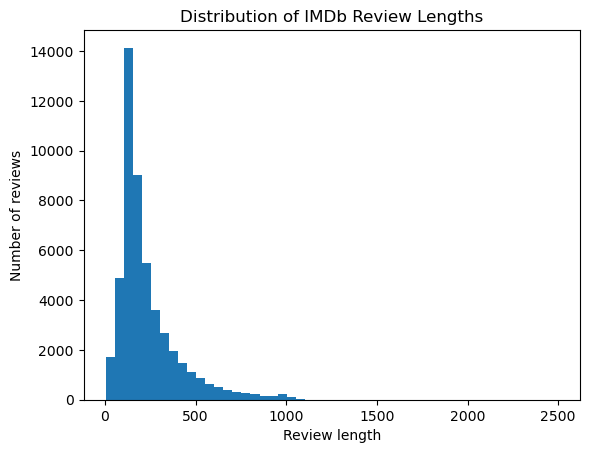

In [16]:
import matplotlib.pyplot as plt

plt.hist(num_tokens, bins=50)
plt.xlabel('Review length')
plt.ylabel('Number of reviews')
plt.title('Distribution of IMDb Review Lengths')
plt.show()

In [17]:
def pad_sequences(data, maxlen):
    padded_data = []
    
    for sentence in data:
        if len(sentence) < maxlen:
            sentence = sentence + [0] * (maxlen - len(sentence))
        else:
            sentence = sentence[:maxlen]
        
        padded_data.append(sentence)
    
    return np.array(padded_data)

print("padding 함수 준비 완료")

padding 함수 준비 완료


In [18]:
x_train_padded = pad_sequences(x_train, maxlen)
x_test_padded = pad_sequences(x_test, maxlen)

x_train_tensor = torch.tensor(x_train_padded, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)

print("x_train_padded shape:", x_train_padded.shape)
print("x_test_padded shape:", x_test_padded.shape)
print("x_train_tensor shape:", x_train_tensor.shape)
print("x_test_tensor shape:", x_test_tensor.shape)

x_train_padded shape: (25000, 580)
x_test_padded shape: (25000, 580)
x_train_tensor shape: torch.Size([25000, 580])
x_test_tensor shape: torch.Size([25000, 580])


In [19]:
# 훈련 데이터 25,000개 중 앞의 10,000개를 검증 데이터로 사용합니다.
x_val = x_train_padded[:10000]
y_val = y_train[:10000]

# 나머지 15,000개를 실제 훈련 데이터로 사용합니다.
partial_x_train = x_train_padded[10000:]
partial_y_train = y_train[10000:]

print("partial_x_train shape:", partial_x_train.shape)
print("partial_y_train shape:", partial_y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

partial_x_train shape: (15000, 580)
partial_y_train shape: (15000,)
x_val shape: (10000, 580)
y_val shape: (10000,)


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

vocab_size = 10000
word_vector_dim = 16

class SentimentModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(SentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.lstm = nn.LSTM(word_vector_dim, 8, batch_first=True)
        self.fc1 = nn.Linear(8, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.embedding(x)
        x, (hn, cn) = self.lstm(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = SentimentModel(vocab_size, word_vector_dim)
print(model)

SentimentModel(
  (embedding): Embedding(10000, 16)
  (lstm): LSTM(16, 8, batch_first=True)
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


In [21]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# numpy 배열을 torch tensor로 변환합니다.
partial_x_train_tensor = torch.tensor(partial_x_train, dtype=torch.long)
partial_y_train_tensor = torch.tensor(partial_y_train, dtype=torch.float)

x_val_tensor = torch.tensor(x_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.float)

# x와 y를 하나의 데이터셋으로 묶습니다.
train_dataset = TensorDataset(partial_x_train_tensor, partial_y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

# batch 단위로 데이터를 꺼낼 수 있게 DataLoader를 만듭니다.
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

print("훈련 데이터 batch 개수:", len(train_loader))
print("검증 데이터 batch 개수:", len(val_loader))

훈련 데이터 batch 개수: 30
검증 데이터 batch 개수: 20


In [22]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.BCELoss()

print("optimizer:", optimizer)
print("loss function:", loss_fn)

optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
loss function: BCELoss()


In [23]:
epochs = 5

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    # =========================
    # 1. Train 단계
    # =========================
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = loss_fn(outputs.squeeze(), labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = (outputs.squeeze() > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # =========================
    # 2. Validation 단계
    # =========================
    model.eval()
    
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels)

            val_loss += loss.item()

            predicted = (outputs.squeeze() > 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f} - "
          f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

Epoch 1/5 - Train Loss: 0.6930, Train Accuracy: 0.5083 - Validation Loss: 0.6942, Validation Accuracy: 0.5008
Epoch 2/5 - Train Loss: 0.6930, Train Accuracy: 0.4993 - Validation Loss: 0.6930, Validation Accuracy: 0.5011
Epoch 3/5 - Train Loss: 0.6928, Train Accuracy: 0.5093 - Validation Loss: 0.6932, Validation Accuracy: 0.5007
Epoch 4/5 - Train Loss: 0.6928, Train Accuracy: 0.5097 - Validation Loss: 0.6930, Validation Accuracy: 0.5013
Epoch 5/5 - Train Loss: 0.6927, Train Accuracy: 0.5067 - Validation Loss: 0.6934, Validation Accuracy: 0.5010


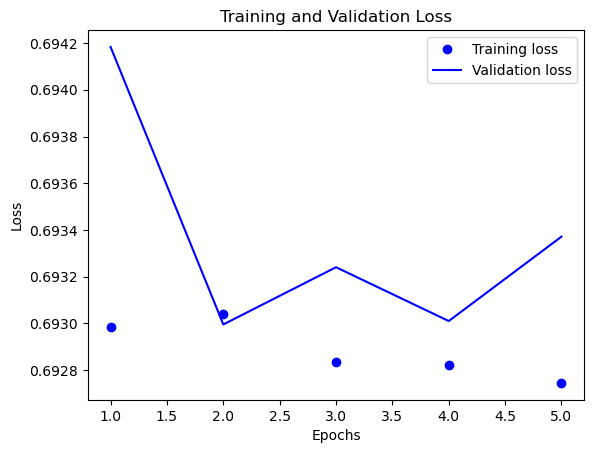

In [24]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
plt.plot(epochs_range, val_losses, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

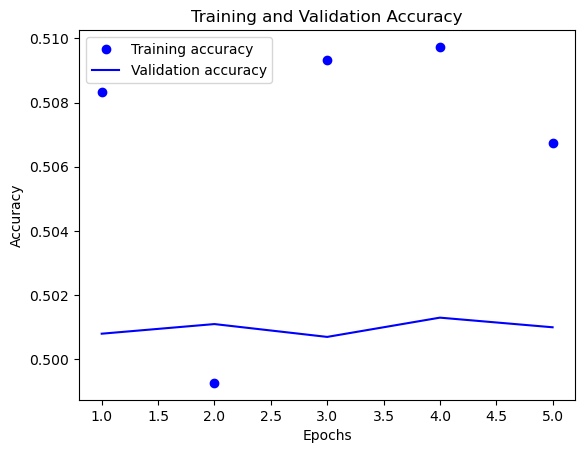

In [25]:
plt.clf()

plt.plot(epochs_range, train_accs, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accs, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [26]:
from torch.utils.data import TensorDataset, DataLoader

test_dataset = TensorDataset(
    x_test_tensor,
    torch.tensor(y_test, dtype=torch.float32)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = loss_fn(outputs.squeeze(), labels)

        test_loss += loss.item()

        predicted = (outputs.squeeze() > 0.5).float()
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f"Test Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {test_correct / test_total:.4f}")

Test Loss: 0.6933
Test Accuracy: 0.5032


1단계: 현재 결과가 낮은 이유 이해
2단계: 1-D CNN 모델로 먼저 바꿔보기
3단계: epoch를 5 → 10~15로 늘리기
4단계: loss/accuracy 그래프 확인
5단계: test accuracy 확인
6단계: 부족하면 LSTM pre-padding 또는 Word2Vec 적용

 퍼실님 중간 피드백에 맞춰
 현실적으로 0.8에 가까워질 가능성이 높은 1-D CNN 실험부터 시작하기!!!

1. 왜 지금 LSTM 정확도가 0.5일까?

현재 padding은 이런 방식이야.
실제 리뷰 단어들 + 0 + 0 + 0 + 0 ...
즉, post padding이야.

그런데 LSTM 모델은 마지막 시점만 사용했어.
x = x[:, -1, :]

문제는 마지막 시점이 실제 단어가 아니라 대부분 <PAD>, 즉 0일 수 있다는 거야.

그래서 모델이 리뷰의 진짜 감정 표현을 보기보다, 마지막의 패딩 정보를 보고 판단했을 가능성이 크다. 현재 LSTM은 문장 내용보다 padding의 영향을 많이 받아서 정확도가 0.5 근처에 머문 것으로 보인다.

2. 가장 먼저 추천하는 방법: 1-D CNN으로 바꾸기

1-D CNN은 LSTM처럼 마지막 단어만 보지 않아.
문장 전체를 훑으면서 중요한 표현을 찾아.

예를 들면:

really good
very boring
waste of time
highly recommend

이런 감성 표현을 필터가 잡아낼 수 있어.

그리고 post padding을 써도 LSTM보다 덜 치명적이야.
그래서 지금 상황에서는 1-D CNN이 더 빠르고 안정적인 개선 실험이야.

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

vocab_size = 10000
word_vector_dim = 128

class CNNTextModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(CNNTextModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, word_vector_dim, padding_idx=0)
        
        self.conv1 = nn.Conv1d(
            in_channels=word_vector_dim,
            out_channels=128,
            kernel_size=7,
            padding=3
        )
        
        self.conv2 = nn.Conv1d(
            in_channels=128,
            out_channels=128,
            kernel_size=7,
            padding=3
        )
        
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)          # (batch, length, embedding_dim)
        x = x.permute(0, 2, 1)         # (batch, embedding_dim, length)
        
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        x = self.global_max_pool(x).squeeze(2)  # (batch, 128)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        
        return x

model = CNNTextModel(vocab_size, word_vector_dim)
print(model)

CNNTextModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (conv1): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


Step 1. 기존 모델 대신 CNN 모델 만들기
작고 약한 LSTM 대신 문장 전체의 감성 표현을 찾는 1-D CNN 모델로 바꾼다.

In [28]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.BCELoss()

print("optimizer와 loss function 준비 완료")

optimizer와 loss function 준비 완료


Step 2. optimizer와 loss 다시 설정하기
새 모델을 만들었으면 optimizer도 반드시 새로 만들어야 한다.

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)

model = model.to(device)

사용 device: cuda


Step 3. 가능하면 GPU 사용 설정하기
모델을 GPU 또는 CPU로 보내서 학습 준비를 한다.

In [30]:
epochs = 10

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs).squeeze()
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, labels)

            val_loss += loss.item()

            predicted = (outputs > 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f} - "
          f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

Epoch 1/10 - Train Loss: 0.6925, Train Accuracy: 0.5211 - Validation Loss: 0.6841, Validation Accuracy: 0.6086
Epoch 2/10 - Train Loss: 0.6426, Train Accuracy: 0.6398 - Validation Loss: 0.5691, Validation Accuracy: 0.6988
Epoch 3/10 - Train Loss: 0.5097, Train Accuracy: 0.7577 - Validation Loss: 0.4723, Validation Accuracy: 0.7752
Epoch 4/10 - Train Loss: 0.3894, Train Accuracy: 0.8351 - Validation Loss: 0.4236, Validation Accuracy: 0.8047
Epoch 5/10 - Train Loss: 0.2868, Train Accuracy: 0.8909 - Validation Loss: 0.4182, Validation Accuracy: 0.8179
Epoch 6/10 - Train Loss: 0.2001, Train Accuracy: 0.9301 - Validation Loss: 0.4147, Validation Accuracy: 0.8287
Epoch 7/10 - Train Loss: 0.1349, Train Accuracy: 0.9585 - Validation Loss: 0.4794, Validation Accuracy: 0.8176
Epoch 8/10 - Train Loss: 0.0882, Train Accuracy: 0.9765 - Validation Loss: 0.4535, Validation Accuracy: 0.8399
Epoch 9/10 - Train Loss: 0.0440, Train Accuracy: 0.9913 - Validation Loss: 0.4872, Validation Accuracy: 0.8411
E

Step 4. CNN 모델 학습하기
CNN 모델을 10 epoch 정도 학습하면서 
validation accuracy가 0.8에 가까워지는지 확인한다.

Train Loss 감소
Validation Loss 감소
Train Accuracy 증가
Validation Accuracy 증가

In [32]:
test_dataset = TensorDataset(
    x_test_tensor,
    torch.tensor(y_test, dtype=torch.float32)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs).squeeze()
        loss = loss_fn(outputs, labels)

        test_loss += loss.item()

        predicted = (outputs > 0.5).float()
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f"Test Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {test_correct / test_total:.4f}")

Test Loss: 0.5436
Test Accuracy: 0.8418


Step 5. 테스트셋 평가하기
새 CNN 모델이 실제 테스트셋에서 0.8 근처까지 올라가는지 확인한다.

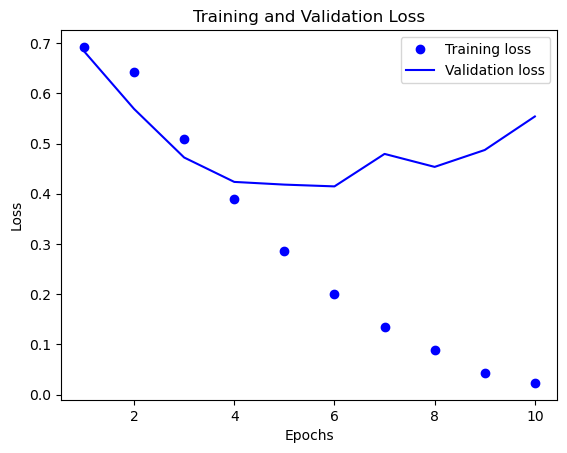

In [33]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
plt.plot(epochs_range, val_losses, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

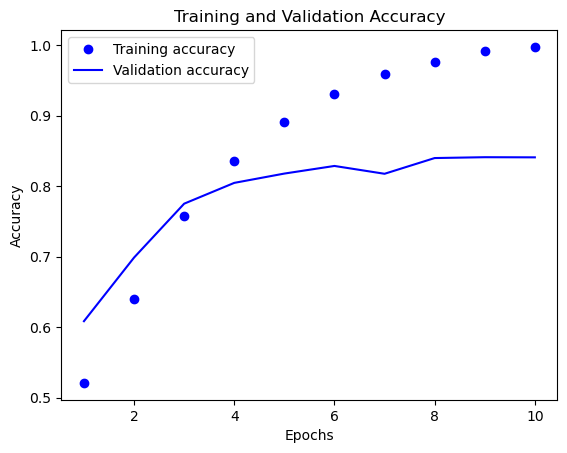

In [34]:
plt.clf()

plt.plot(epochs_range, train_accs, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accs, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

현재 CNN 모델은 LSTM보다 훨씬 잘 학습했고, validation accuracy가 약 0.84까지 올라갔으므로 Test Accuracy 0.8 목표를 달성할 가능성이 높다.

지금 바로 할 일: Test Accuracy 확인

In [35]:
test_dataset = TensorDataset(
    x_test_tensor,
    torch.tensor(y_test, dtype=torch.float32)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs).squeeze()
        loss = loss_fn(outputs, labels)

        test_loss += loss.item()

        predicted = (outputs > 0.5).float()
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f"Test Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {test_correct / test_total:.4f}")

Test Loss: 0.5436
Test Accuracy: 0.8418


기본 LSTM 모델은 Test Accuracy가 약 0.50 수준으로 낮게 나타났다. 이는 post-padding 이후 마지막 시점의 출력을 사용하는 구조에서 padding 정보가 모델 판단에 영향을 주었을 가능성이 있다. 이후 1-D CNN 모델로 변경하여 문장 전체에서 감성 표현 패턴을 추출하도록 설계한 결과, validation accuracy가 약 0.84까지 상승하였다. 따라서 텍스트 감성분석에서 RNN만이 유일한 선택지는 아니며, 1-D CNN도 효과적인 대안이 될 수 있음을 확인하였다.

1-D CNN 모델로 변경한 결과 Test Accuracy가 0.8418까지 상승하여, 목표였던 0.8 이상을 달성했다.

In [36]:
embedding_layer = model.embedding
weights = embedding_layer.weight.detach().cpu().numpy()

print("Embedding weight shape:", weights.shape)

Embedding weight shape: (10000, 128)


In [38]:
!mkdir -p ~/work/sentiment_classification/word2vec_emb
!ls -al ~/work/sentiment_classification

total 12
drwxr-sr-x  3 jovyan users 4096 Jun 12 06:47 .
drwxrwsr-x 14 root   users 4096 Jun 12 07:15 ..
lrwxrwxrwx  1 jovyan users   17 Jun 12 03:35 data -> /home/jovyan/data
drwxr-sr-x  2 jovyan users 4096 Jun 12 06:47 word2vec_emb


In [39]:
import os

word2vec_file_path = os.path.join(
    os.getenv('HOME'),
    'work/sentiment_classification/word2vec_emb/word2vec.txt'
)

with open(word2vec_file_path, 'w') as f:
    # 특수 토큰 4개를 제외하고 저장합니다.
    f.write('{} {}\n'.format(vocab_size - 4, word_vector_dim))

    vectors = model.embedding.weight.detach().cpu().numpy()

    for i in range(4, vocab_size):
        word = index_to_word.get(i, '<UNK>')
        vector_str = ' '.join(map(str, vectors[i, :]))
        f.write('{} {}\n'.format(word, vector_str))

print("저장 완료:", word2vec_file_path)

저장 완료: /home/jovyan/work/sentiment_classification/word2vec_emb/word2vec.txt


In [40]:
!ls -lh ~/work/sentiment_classification/word2vec_emb

total 14M
-rw-r--r-- 1 jovyan users 14M Jun 12 07:56 word2vec.txt


In [41]:
from gensim.models.keyedvectors import Word2VecKeyedVectors

word_vectors = Word2VecKeyedVectors.load_word2vec_format(
    word2vec_file_path,
    binary=False
)

print("불러오기 완료")
print("단어 개수:", len(word_vectors.key_to_index))
print("vector 크기:", word_vectors.vector_size)

불러오기 완료
단어 개수: 9996
vector 크기: 128


In [42]:
word_vectors.similar_by_word("love")

[('washed', 0.3334603011608124),
 ('traditions', 0.3046894669532776),
 ('schlock', 0.30207839608192444),
 ('length', 0.2873021364212036),
 ('communicate', 0.2861488461494446),
 ('travelling', 0.2776067554950714),
 ('find', 0.2714669108390808),
 ('stanwyck', 0.26767876744270325),
 ('plants', 0.26555752754211426),
 ('embrace', 0.2635810077190399)]

In [43]:
!ls -lh ~/work/sentiment_classification/data | grep -E "GoogleNews|word2vec|Word2Vec|ko"

In [44]:
!ls -lh ~/work/sentiment_classification/data

lrwxrwxrwx 1 jovyan users 17 Jun 12 03:35 /home/jovyan/work/sentiment_classification/data -> /home/jovyan/data
